# Notebook 02 - EDA tables annexes & Feature Engineering

#### Objectif
Explorer les 6 tables annexes du dataset Home Credit, construire des features agrégées
et les joindres à `application_train/test`pour obtenir un jeu de données enrichi.

#### Stratégie d'agrégation
On remonte l'information du bas vers le haut, niveau par niveau:

**Branche Bureau (externe)** : `bureau_balance` → `bureau` → client (`SK_ID_CURR`)  
**Branche Home Credit (interne)** : `POS_CASH / installments / credit_card` → `previous_application` → client (`SK_ID_CURR`)

In [1]:
# Imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys

sys.path.append('..')
from src.utils import overview, reduce_memory

sns.set_style("whitegrid")
pd.set_option('display.max_columns', None)

---
## 1. Bureau Balance (`bureau_balance.csv`)



In [4]:
bb = pd.read_csv('../data/raw/bureau_balance.csv')
overview(bb, "bureau_balance")


  bureau_balance
  Shape : 27299925 lignes x 3 colonnes
  Mémoire : 2020.2 Mo
  Doublons : 0
  Valeurs manquantes : 0 colonnes
    Aucune !


,missing_pct,dtype


- 27 millions de lignes pour seulement 3 colonnes.
- Chaque ligne = un mois de suivi pour un crédit bureau donné.
- Pas de doublons, pas de valeurs manquantes 
- 2 Go en mémoire on utilisera reduce_memory

In [5]:
# réduction de la mémoire
bb = reduce_memory(bb)
overview(bb, "bureau_balance")

Mémoire : 2020.2 Mo → 1719.9 Mo (15% de réduction)

  bureau_balance
  Shape : 27299925 lignes x 3 colonnes
  Mémoire : 1719.9 Mo
  Doublons : 0
  Valeurs manquantes : 0 colonnes
    Aucune !


,missing_pct,dtype


In [7]:
bb.info()

<class 'pandas.DataFrame'>
RangeIndex: 27299925 entries, 0 to 27299924
Data columns (total 3 columns):
 #   Column          Dtype
---  ------          -----
 0   SK_ID_BUREAU    int32
 1   MONTHS_BALANCE  int8 
 2   STATUS          str  
dtypes: int32(1), int8(1), str(1)
memory usage: 338.5 MB


In [9]:
print("Nombre de crédits uniques :", bb['SK_ID_BUREAU'].nunique())
print("Mois par crédit (médiane) :", bb.groupby('SK_ID_BUREAU')['MONTHS_BALANCE'].count().median())
print()
print("MONTHS_BALANCE :")
print(bb['MONTHS_BALANCE'].describe())
print()
print("STATUS — distribution :")
print(bb['STATUS'].value_counts(normalize=True).round(4) * 100)

Nombre de crédits uniques : 817395
Mois par crédit (médiane) : 26.0

MONTHS_BALANCE :
count    2.729992e+07
mean    -3.074169e+01
std      2.386451e+01
min     -9.600000e+01
25%     -4.600000e+01
50%     -2.500000e+01
75%     -1.100000e+01
max      0.000000e+00
Name: MONTHS_BALANCE, dtype: float64

STATUS — distribution :
STATUS
C    49.99
0    27.47
X    21.28
1     0.89
5     0.23
2     0.09
3     0.03
4     0.02
Name: proportion, dtype: float64


Les résultats sont interessant, on observe que la moitié des mois sont au statut C(crédit clos), 27% au statut 0 (pas de retard), 21% status X (inconnu).
Les vrais retards de paiement (status 1 à 5) représente à peine 1,3%. C'est cohérent avec le désequilivre de classes qu'on avait observer dans nb1

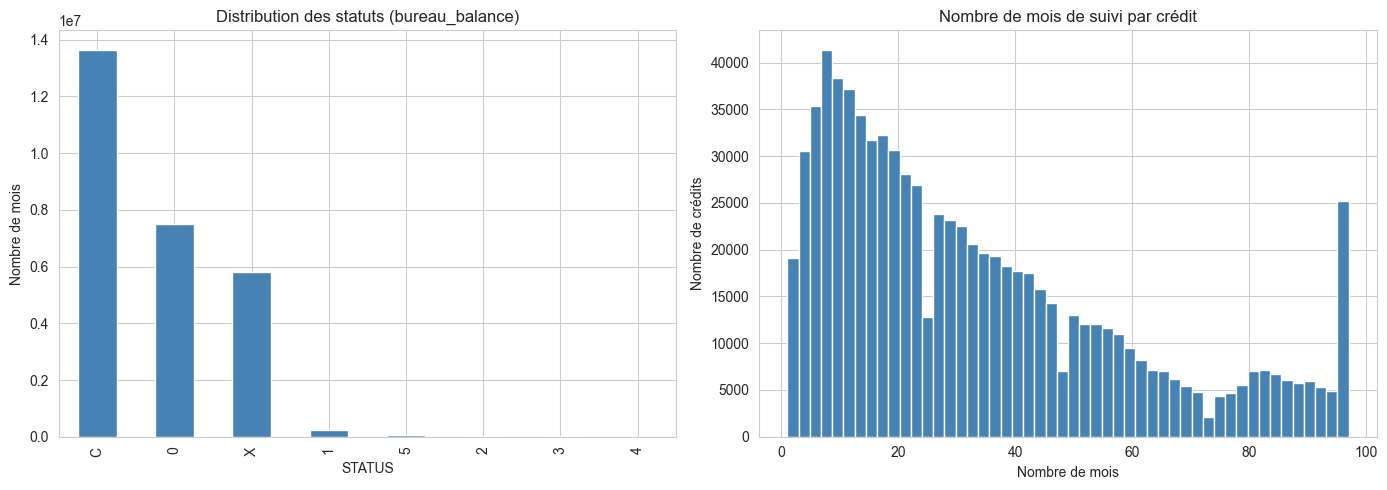

In [10]:
# Distribution des statuts
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Graphique 1 : répartition globale des statuts
bb['STATUS'].value_counts().plot.bar(ax=axes[0], color='steelblue')
axes[0].set_title('Distribution des statuts (bureau_balance)')
axes[0].set_ylabel('Nombre de mois')

# Graphique 2 : profondeur temporelle par crédit
months_per_credit = bb.groupby('SK_ID_BUREAU')['MONTHS_BALANCE'].count()
axes[1].hist(months_per_credit, bins=50, color='steelblue', edgecolor='white')
axes[1].set_title('Nombre de mois de suivi par crédit')
axes[1].set_xlabel('Nombre de mois')
axes[1].set_ylabel('Nombre de crédits')

plt.tight_layout()
plt.show()

- Confirme visuellement ce qu'on avait en chiffres. Les status de retard (1 à 5) sont quasi invisibles à cette échelle.
- La distribution est asymetrique à droite avec un pic autour de 5-15 mois de suivi. Mais on note un rebond à 96 mois. C'est bcp de crédit avec le maximum d'historique (8années).

In [11]:
# Agrégation de bureau_balance par SK_ID_BUREAU
bb_agg = bb.groupby('SK_ID_BUREAU').agg(
    BB_MONTHS_COUNT=('MONTHS_BALANCE', 'count'),           # profondeur d'historique
    BB_MONTHS_MIN=('MONTHS_BALANCE', 'min'),               # mois le plus ancien
)

# Proportion de chaque statut par crédit (one-hot puis moyenne)
status_dummies = pd.get_dummies(bb['STATUS'], prefix='BB_STATUS')
status_dummies['SK_ID_BUREAU'] = bb['SK_ID_BUREAU']
status_agg = status_dummies.groupby('SK_ID_BUREAU').mean()

# Joindre les deux
bb_agg = bb_agg.join(status_agg)

print(bb_agg.shape)
bb_agg.head()

(817395, 10)


,BB_MONTHS_COUNT,BB_MONTHS_MIN,BB_STATUS_0,BB_STATUS_1,BB_STATUS_2,BB_STATUS_3,BB_STATUS_4,BB_STATUS_5,BB_STATUS_C,BB_STATUS_X
SK_ID_BUREAU,,,,,,,,,,
5001709,97,-96,0.000000,0.0,0.0,0.0,0.0,0.0,0.886598,0.113402
5001710,83,-82,0.060241,0.0,0.0,0.0,0.0,0.0,0.578313,0.361446
5001711,4,-3,0.750000,0.0,0.0,0.0,0.0,0.0,0.000000,0.250000
5001712,19,-18,0.526316,0.0,0.0,0.0,0.0,0.0,0.473684,0.000000
5001713,22,-21,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,1.000000


Table la plus profonde de la branche bureau. Contient le suivi **mensuel** de chaque 
crédit rapporté au Credit Bureau.

- **SK_BUREAU_ID** : identifiant du crédit bureau (jointure avec `bureau.csv`)
- **MONTHS_BALANCE** : mois relatif à la date de demande (-1 = plus récent)
- **STATUS** : statut du crédit ce mois-là (C=clos, X=inconnu, 0=pas de retard, 
  1=DPD 1-30j, 2=DPD 31-60j, ... 5=DPD 120+ ou cédé)

---
## 2. Bureau (`bureau.csv`)


In [12]:
bureau = pd.read_csv('../data/raw/bureau.csv')
bureau = reduce_memory(bureau)
overview(bureau, "bureau")

Mémoire : 537.0 Mo → 428.9 Mo (20% de réduction)

  bureau
  Shape : 1716428 lignes x 17 colonnes
  Mémoire : 428.9 Mo
  Doublons : 0
  Valeurs manquantes : 6 colonnes
                        missing_pct    dtype
AMT_ANNUITY                    71.5  float32
AMT_CREDIT_MAX_OVERDUE         65.5  float32
DAYS_ENDDATE_FACT              36.9  float32
AMT_CREDIT_SUM_LIMIT           34.5  float32
AMT_CREDIT_SUM_DEBT            15.0  float32
DAYS_CREDIT_ENDDATE             6.1  float32


,missing_pct,dtype
AMT_ANNUITY,71.5,float32
AMT_CREDIT_MAX_OVERDUE,65.5,float32
DAYS_ENDDATE_FACT,36.9,float32
AMT_CREDIT_SUM_LIMIT,34.5,float32
AMT_CREDIT_SUM_DEBT,15.0,float32
DAYS_CREDIT_ENDDATE,6.1,float32


In [13]:
bureau.info()

<class 'pandas.DataFrame'>
RangeIndex: 1716428 entries, 0 to 1716427
Data columns (total 17 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   SK_ID_CURR              int32  
 1   SK_ID_BUREAU            int32  
 2   CREDIT_ACTIVE           str    
 3   CREDIT_CURRENCY         str    
 4   DAYS_CREDIT             int16  
 5   CREDIT_DAY_OVERDUE      int16  
 6   DAYS_CREDIT_ENDDATE     float32
 7   DAYS_ENDDATE_FACT       float32
 8   AMT_CREDIT_MAX_OVERDUE  float32
 9   CNT_CREDIT_PROLONG      int8   
 10  AMT_CREDIT_SUM          float32
 11  AMT_CREDIT_SUM_DEBT     float32
 12  AMT_CREDIT_SUM_LIMIT    float32
 13  AMT_CREDIT_SUM_OVERDUE  float32
 14  CREDIT_TYPE             str    
 15  DAYS_CREDIT_UPDATE      int32  
 16  AMT_ANNUITY             float32
dtypes: float32(8), int16(2), int32(3), int8(1), str(3)
memory usage: 119.5 MB


Historique des crédits du client auprès d'autres institutions, rapportés au Credit Bureau.
Une ligne = un crédit. Jointure avec `application_train/test` via `SK_ID_CURR`.

17 colonnes dont :
- Infos temporelles : `DAYS_CREDIT`, `DAYS_CREDIT_ENDDATE`, `DAYS_ENDDATE_FACT`
- Montants : `AMT_CREDIT_SUM`, `AMT_CREDIT_SUM_DEBT`, `AMT_CREDIT_SUM_OVERDUE`
- Comportement : `CREDIT_ACTIVE`, `CREDIT_DAY_OVERDUE`, `CNT_CREDIT_PROLONG`

In [14]:
# Variables catégorielles
print("CREDIT_ACTIVE :")
print(bureau['CREDIT_ACTIVE'].value_counts())
print()
print("CREDIT_CURRENCY :")
print(bureau['CREDIT_CURRENCY'].value_counts())
print()
print("CREDIT_TYPE :")
print(bureau['CREDIT_TYPE'].value_counts())
print()

# Variables numériques clés
print("CREDIT_DAY_OVERDUE :")
print(bureau['CREDIT_DAY_OVERDUE'].describe())
print()
print("AMT_CREDIT_SUM :")
print(bureau['AMT_CREDIT_SUM'].describe())

CREDIT_ACTIVE :
CREDIT_ACTIVE
Closed      1079273
Active       630607
Sold           6527
Bad debt         21
Name: count, dtype: int64

CREDIT_CURRENCY :
CREDIT_CURRENCY
currency 1    1715020
currency 2       1224
currency 3        174
currency 4         10
Name: count, dtype: int64

CREDIT_TYPE :
CREDIT_TYPE
Consumer credit                                 1251615
Credit card                                      402195
Car loan                                          27690
Mortgage                                          18391
Microloan                                         12413
Loan for business development                      1975
Another type of loan                               1017
Unknown type of loan                                555
Loan for working capital replenishment              469
Cash loan (non-earmarked)                            56
Real estate loan                                     27
Loan for the purchase of equipment                   19
Loan for purchas

In [15]:
# Variable numérique 
print("CREDIT_DAY_OVERDUE :")
print(bureau['CREDIT_DAY_OVERDUE'].describe())
print()
print("AMT_CREDIT_SUM :")
print(bureau['AMT_CREDIT_SUM'].describe())
print()
print("CNT_CREDIT_PROLONG :")
print(bureau['CNT_CREDIT_PROLONG'].value_counts())

CREDIT_DAY_OVERDUE :
count    1.716428e+06
mean     8.181666e-01
std      3.654443e+01
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      2.792000e+03
Name: CREDIT_DAY_OVERDUE, dtype: float64

AMT_CREDIT_SUM :
count    1.716415e+06
mean     3.549946e+05
std      1.149811e+06
min      0.000000e+00
25%      5.130000e+04
50%      1.255185e+05
75%      3.150000e+05
max      5.850000e+08
Name: AMT_CREDIT_SUM, dtype: float64

CNT_CREDIT_PROLONG :
CNT_CREDIT_PROLONG
0    1707314
1       7620
2       1222
3        191
4         54
5         21
9          2
6          2
8          1
7          1
Name: count, dtype: int64


In [16]:
credits_per_client = bureau.groupby('SK_ID_CURR')['SK_ID_BUREAU'].count()
print("Crédits par client :")
print(credits_per_client.describe())

Crédits par client :
count    305811.000000
mean          5.612709
std           4.430354
min           1.000000
25%           2.000000
50%           4.000000
75%           8.000000
max         116.000000
Name: SK_ID_BUREAU, dtype: float64


In [17]:
# Explorer les outliers de AMT_CREDIT_SUM
print("Percentiles hauts :")
for p in [95, 99, 99.5, 99.9, 100]:
    val = bureau['AMT_CREDIT_SUM'].quantile(p/100)
    print(f"  {p}e percentile : {val:,.0f}")

print()
print(f"Crédits > 10M : {(bureau['AMT_CREDIT_SUM'] > 10_000_000).sum()}")
print(f"Crédits > 50M : {(bureau['AMT_CREDIT_SUM'] > 50_000_000).sum()}")
print(f"Crédits > 100M : {(bureau['AMT_CREDIT_SUM'] > 100_000_000).sum()}")

print()
print("Détail des crédits > 50M :")
print(bureau[bureau['AMT_CREDIT_SUM'] > 50_000_000][
    ['SK_ID_CURR', 'CREDIT_ACTIVE', 'CREDIT_TYPE', 'AMT_CREDIT_SUM', 'AMT_CREDIT_SUM_DEBT']
])

Percentiles hauts :
  95e percentile : 1,350,000
  99e percentile : 3,700,916
  99.5e percentile : 5,796,000
  99.9e percentile : 11,021,004
  100e percentile : 585,000,000

Crédits > 10M : 2183
Crédits > 50M : 44
Crédits > 100M : 19

Détail des crédits > 50M :
         SK_ID_CURR CREDIT_ACTIVE                    CREDIT_TYPE  \
137351       271538        Closed                       Mortgage   
174615       120340        Active                Consumer credit   
344642       169764        Active                       Car loan   
421897       404604        Active                       Mortgage   
488411       363076        Active                Consumer credit   
488416       363076        Closed                Consumer credit   
489961       363076        Active                Consumer credit   
512592       406671        Active                Consumer credit   
513359       413332          Sold                       Mortgage   
716826       442645        Closed                Consumer 

#### Synthèse bureau.csv

**Shape** : 1 716 428 lignes × 17 colonnes 

**Qualité des données** :
- Aucun doublon
- 6 colonnes avec valeurs manquantes, toutes explicables :
  - `AMT_ANNUITY` (71.5%) et `AMT_CREDIT_MAX_OVERDUE` (65.5%) : info non transmise par le bureau
  - `DAYS_ENDDATE_FACT` (36.9%) : n'existe que pour les crédits clos
  - `AMT_CREDIT_SUM_LIMIT` (34.5%) : ne concerne que les cartes de crédit
- Pas d'anomalie à corriger

**Observations clés** :
- 305 811 clients représentés (quasi-totalité du train), médiane de 4 crédits par client
- 63% de crédits clos, 37% actifs
- `CREDIT_CURRENCY` quasi-uniforme (99.9% currency 1) → peu utile comme feature
- Crédit à la consommation dominant (73%), suivi des cartes de crédit (23%)
- Retards de paiement rares (médiane à 0 jours) mais extrêmes quand ils existent (max 2 792 jours)
- Prolongations très rares (99.5% des crédits jamais prolongés)
- Outliers importants dans `AMT_CREDIT_SUM` (max 585M) → cas suspect avec aucune informations sur la dette.

#### Agrégation bureau + bureau_balance → client

In [18]:
# Joindre bureau_balance à bureau
bureau = bureau.merge(bb_agg, on='SK_ID_BUREAU', how='left')
print(f"Après jointure {bureau.shape}")

# Vérification de nombre de crédit qui n'ont pas de donnée bureau_balance
print(f"Crédits sans bureau_balance : {bureau['BB_MONTHS_COUNT'].isna().sum()}"
      f"({(bureau['BB_MONTHS_COUNT'].isna().mean() * 100):.1f}%)")

Après jointure (1716428, 27)
Crédits sans bureau_balance : 942074(54.9%)


In [19]:
bureau_agg = bureau.groupby('SK_ID_CURR').agg(
    # Combien de crédits au total et combien sont encore actifs
    BUREAU_CREDIT_COUNT=('SK_ID_BUREAU', 'count'),
    BUREAU_ACTIVE_COUNT=('CREDIT_ACTIVE', lambda x: (x == 'Active').sum()),
    
    # Montants : vision globale de l'endettement externe
    BUREAU_AMT_CREDIT_SUM_mean=('AMT_CREDIT_SUM', 'mean'),
    BUREAU_AMT_CREDIT_SUM_sum=('AMT_CREDIT_SUM', 'sum'),
    BUREAU_AMT_DEBT_mean=('AMT_CREDIT_SUM_DEBT', 'mean'),
    BUREAU_AMT_OVERDUE_mean=('AMT_CREDIT_SUM_OVERDUE', 'mean'),
    
    # Retards : le pire cas est le plus révélateur
    BUREAU_DAYS_OVERDUE_max=('CREDIT_DAY_OVERDUE', 'max'),
    BUREAU_AMT_MAX_OVERDUE_max=('AMT_CREDIT_MAX_OVERDUE', 'max'),
    
    # Prolongations : signal de difficulté
    BUREAU_PROLONG_sum=('CNT_CREDIT_PROLONG', 'sum'),
    
    # Ancienneté : depuis quand le client emprunte
    BUREAU_DAYS_CREDIT_min=('DAYS_CREDIT', 'min'),
    BUREAU_DAYS_CREDIT_mean=('DAYS_CREDIT', 'mean'),
    
    # Bureau balance : comportement de paiement mensuel
    BUREAU_BB_STATUS_0_mean=('BB_STATUS_0', 'mean'),
    BUREAU_BB_STATUS_C_mean=('BB_STATUS_C', 'mean'),
    BUREAU_BB_STATUS_DPD_mean=('BB_STATUS_1', 'mean'),
)

print(f"Shape : {bureau_agg.shape}")
bureau_agg.head()

Shape : (305811, 14)


,BUREAU_CREDIT_COUNT,BUREAU_ACTIVE_COUNT,BUREAU_AMT_CREDIT_SUM_mean,BUREAU_AMT_CREDIT_SUM_sum,BUREAU_AMT_DEBT_mean,BUREAU_AMT_OVERDUE_mean,BUREAU_DAYS_OVERDUE_max,BUREAU_AMT_MAX_OVERDUE_max,BUREAU_PROLONG_sum,BUREAU_DAYS_CREDIT_min,BUREAU_DAYS_CREDIT_mean,BUREAU_BB_STATUS_0_mean,BUREAU_BB_STATUS_C_mean,BUREAU_BB_STATUS_DPD_mean
SK_ID_CURR,,,,,,,,,,,,,,
100001,7,3,207623.578125,1.453365e+06,85240.929688,0.0,0,NaN,0,-1572,-735.000000,0.336651,0.441240,0.007519
100002,8,2,108131.945312,8.650556e+05,49156.199219,0.0,0,5043.64502,0,-1437,-874.000000,0.406960,0.175426,0.255682
100003,4,1,254350.125000,1.017400e+06,0.000000,0.0,0,0.00000,0,-2586,-1400.750000,NaN,NaN,NaN
100004,2,0,94518.898438,1.890378e+05,0.000000,0.0,0,0.00000,0,-1326,-867.000000,NaN,NaN,NaN
100005,3,2,219042.000000,6.571260e+05,189469.500000,0.0,0,0.00000,0,-373,-190.666667,0.735043,0.128205,0.000000


#### Synthèse branche Bureau

`bureau_balance` (27M lignes) → agrégé par crédit (`SK_ID_BUREAU`) → joint à `bureau` (1.7M lignes) → agrégé par client (`SK_ID_CURR`) → **`bureau_agg` : 305 811 clients × 14 features**

Features créées :
- Volume : nombre de crédits, nombre de crédits actifs
- Endettement : montant moyen/total des crédits, dette moyenne, montant moyen en retard
- Risque : pire retard en jours, pire montant en retard, total prolongations
- Historique : ancienneté du premier crédit, ancienneté moyenne
- Comportement mensuel (depuis bureau_balance) : % mois sans retard, % mois clos, % mois DPD

---
## 3. POS_CASH_balance (`POS_CASH_balance.csv`)

Suivi mensuel des prêts cash et POS (point de vente) précédents chez Home Credit.

In [20]:
pos = pd.read_csv('../data/raw/POS_CASH_balance.csv')
pos = reduce_memory(pos)
overview(pos, "POS_CASH_balance")

Mémoire : 1192.5 Mo → 842.4 Mo (29% de réduction)

  POS_CASH_balance
  Shape : 10001358 lignes x 8 colonnes
  Mémoire : 842.4 Mo
  Doublons : 0
  Valeurs manquantes : 2 colonnes
                       missing_pct    dtype
CNT_INSTALMENT                 0.3  float32
CNT_INSTALMENT_FUTURE          0.3  float32


,missing_pct,dtype
CNT_INSTALMENT,0.3,float32
CNT_INSTALMENT_FUTURE,0.3,float32


10 millions de lignes, quasi aucune valeur manquante (0.3% sur 2 colonnes)

In [22]:
pos.info()

<class 'pandas.DataFrame'>
RangeIndex: 10001358 entries, 0 to 10001357
Data columns (total 8 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   SK_ID_PREV             int32  
 1   SK_ID_CURR             int32  
 2   MONTHS_BALANCE         int8   
 3   CNT_INSTALMENT         float32
 4   CNT_INSTALMENT_FUTURE  float32
 5   NAME_CONTRACT_STATUS   str    
 6   SK_DPD                 int16  
 7   SK_DPD_DEF             int16  
dtypes: float32(2), int16(2), int32(2), int8(1), str(1)
memory usage: 276.6 MB


In [21]:
print("Nombre de prêts uniques :", pos['SK_ID_PREV'].nunique())
print("Nombre de clients uniques :", pos['SK_ID_CURR'].nunique())
print("Mois par prêt (médiane) :", pos.groupby('SK_ID_PREV')['MONTHS_BALANCE'].count().median())
print()
print("NAME_CONTRACT_STATUS :")
print(pos['NAME_CONTRACT_STATUS'].value_counts(normalize=True).round(4) * 100)
print()
print("SK_DPD :")
print(pos['SK_DPD'].describe())
print()
print("SK_DPD_DEF :")
print(pos['SK_DPD_DEF'].describe())

Nombre de prêts uniques : 936325
Nombre de clients uniques : 337252
Mois par prêt (médiane) : 10.0

NAME_CONTRACT_STATUS :
NAME_CONTRACT_STATUS
Active                   91.50
Completed                 7.45
Signed                    0.87
Demand                    0.07
Returned to the store     0.05
Approved                  0.05
Amortized debt            0.01
Canceled                  0.00
XNA                       0.00
Name: proportion, dtype: float64

SK_DPD :
count    1.000136e+07
mean     1.160693e+01
std      1.327140e+02
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      4.231000e+03
Name: SK_DPD, dtype: float64

SK_DPD_DEF :
count    1.000136e+07
mean     6.544684e-01
std      3.276249e+01
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      3.595000e+03
Name: SK_DPD_DEF, dtype: float64


**Colonnes :**
- `SK_ID_PREV` (int32) : identifiant du prêt précédent (jointure avec `previous_application`)
- `SK_ID_CURR` (int32) : identifiant du client
- `MONTHS_BALANCE` (int8) : mois relatif à la demande (-1 = plus récent)
- `CNT_INSTALMENT` (float32) : nombre total d'échéances prévues (0.3% NaN)
- `CNT_INSTALMENT_FUTURE` (float32) : échéances restantes à payer (0.3% NaN)
- `NAME_CONTRACT_STATUS` (str) : statut du contrat ce mois-là (91.5% Active, 7.5% Completed)
- `SK_DPD` (int16) : jours de retard ce mois-là
- `SK_DPD_DEF` (int16) : jours de retard avec tolérance (petits montants ignorés)

In [23]:
# Agrégation de POS_CASH_balance par SK_ID_PREV
pos_agg = pos.groupby('SK_ID_PREV').agg(
    POS_MONTHS_COUNT=('MONTHS_BALANCE', 'count'),
    POS_DPD_max=('SK_DPD', 'max'),
    POS_DPD_DEF_max=('SK_DPD_DEF', 'max'),
    POS_DPD_DEF_mean=('SK_DPD_DEF', 'mean'),
)

print(f"Shape : {pos_agg.shape}")
pos_agg.head()

Shape : (936325, 4)


,POS_MONTHS_COUNT,POS_DPD_max,POS_DPD_DEF_max,POS_DPD_DEF_mean
SK_ID_PREV,,,,
1000001,3,0,0,0.0
1000002,5,0,0,0.0
1000003,4,0,0,0.0
1000004,8,0,0,0.0
1000005,11,0,0,0.0


#### Synthèse POS_CASH_balance

**Shape** : 10 001 358 lignes × 8 colonnes (une ligne = un mois de suivi pour un prêt POS/Cash)

**Qualité des données** :
- Aucun doublon
- 2 colonnes avec valeurs manquantes négligeables (0.3%)
- Pas d'anomalie à corriger

**Observations clés** :
- 337 252 clients, 936 325 prêts, médiane de 10 mois de suivi par prêt
- Statuts : 91.5% Active, 7.5% Completed, le reste anecdotique
- Retards rares (médiane à 0) mais extrêmes quand ils existent (max 4 231 jours)
- SK_DPD_DEF (avec tolérance) beaucoup plus faible que SK_DPD → la majorité des retards concernent de petits montants

**Agrégation** : `pos_agg` — 936 325 prêts × 4 features (profondeur historique, pire retard brut, pire retard réel, retard réel moyen)

---
## 4. Installments Payments (`installments_payments.csv`)

Comparaison entre ce que le client devait payer et ce qu'il a réellement payé 
pour chaque échéance de ses prêts précédents chez Home Credit.

In [24]:
ins = pd.read_csv('../data/raw/installments_payments.csv')
ins = reduce_memory(ins)
overview(ins, "installments_payments")

Mémoire : 870.7 Mo → 408.2 Mo (53% de réduction)

  installments_payments
  Shape : 13605401 lignes x 8 colonnes
  Mémoire : 408.2 Mo
  Doublons : 0
  Valeurs manquantes : 0 colonnes
    Aucune !


,missing_pct,dtype


In [25]:
ins.info()

<class 'pandas.DataFrame'>
RangeIndex: 13605401 entries, 0 to 13605400
Data columns (total 8 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   SK_ID_PREV              int32  
 1   SK_ID_CURR              int32  
 2   NUM_INSTALMENT_VERSION  float32
 3   NUM_INSTALMENT_NUMBER   int16  
 4   DAYS_INSTALMENT         float32
 5   DAYS_ENTRY_PAYMENT      float32
 6   AMT_INSTALMENT          float32
 7   AMT_PAYMENT             float32
dtypes: float32(5), int16(1), int32(2)
memory usage: 389.3 MB


13.6 millions de lignes, aucun NaN, aucun doublon 

**Colonnes :**
- `SK_ID_PREV` (int32) : identifiant du prêt précédent
- `SK_ID_CURR` (int32) : identifiant du client
- `NUM_INSTALMENT_VERSION` (float32) : version du calendrier de paiement (un changement = modification des conditions)
- `NUM_INSTALMENT_NUMBER` (int16) : numéro de l'échéance
- `DAYS_INSTALMENT` (float32) : quand l'échéance devait être payée
- `DAYS_ENTRY_PAYMENT` (float32) : quand l'échéance a été réellement payée
- `AMT_INSTALMENT` (float32) : montant prévu de l'échéance
- `AMT_PAYMENT` (float32) : montant réellement payé

In [26]:
print("Nombre de prêts uniques :", ins['SK_ID_PREV'].nunique())
print("Nombre de clients uniques :", ins['SK_ID_CURR'].nunique())
print()
print("AMT_INSTALMENT (montant prévu) :")
print(ins['AMT_INSTALMENT'].describe())
print()
print("AMT_PAYMENT (montant payé) :")
print(ins['AMT_PAYMENT'].describe())

Nombre de prêts uniques : 997752
Nombre de clients uniques : 339587

AMT_INSTALMENT (montant prévu) :
count    1.360540e+07
mean     1.705091e+04
std      5.057025e+04
min      0.000000e+00
25%      4.226085e+03
50%      8.884080e+03
75%      1.671021e+04
max      3.771488e+06
Name: AMT_INSTALMENT, dtype: float64

AMT_PAYMENT (montant payé) :
count    1.360250e+07
mean     1.723822e+04
std      5.473579e+04
min      0.000000e+00
25%      3.398265e+03
50%      8.125515e+03
75%      1.610842e+04
max      3.771488e+06
Name: AMT_PAYMENT, dtype: float64


In [27]:
# Features calculées
ins['PAYMENT_DIFF'] = ins['AMT_INSTALMENT'] - ins['AMT_PAYMENT']
ins['PAYMENT_RATIO'] = ins['AMT_PAYMENT'] / ins['AMT_INSTALMENT'].replace(0, np.nan)
ins['DAYS_LATE'] = ins['DAYS_ENTRY_PAYMENT'] - ins['DAYS_INSTALMENT']

print("PAYMENT_DIFF (positif = sous-paiement) :")
print(ins['PAYMENT_DIFF'].describe())
print()
print("DAYS_LATE (positif = en retard) :")
print(ins['DAYS_LATE'].describe())

PAYMENT_DIFF (positif = sous-paiement) :
count    1.360250e+07
mean    -1.871538e+02
std      1.910673e+04
min     -2.630909e+06
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      2.424726e+06
Name: PAYMENT_DIFF, dtype: float64

DAYS_LATE (positif = en retard) :
count    1.360250e+07
mean    -8.787405e+00
std      2.553990e+01
min     -3.189000e+03
25%     -1.400000e+01
50%     -6.000000e+00
75%      0.000000e+00
max      2.884000e+03
Name: DAYS_LATE, dtype: float64


In [28]:
ins_agg = ins.groupby('SK_ID_PREV').agg(
    INS_COUNT=('NUM_INSTALMENT_NUMBER', 'count'),
    INS_PAYMENT_DIFF_mean=('PAYMENT_DIFF', 'mean'),
    INS_PAYMENT_RATIO_mean=('PAYMENT_RATIO', 'mean'),
    INS_DAYS_LATE_mean=('DAYS_LATE', 'mean'),
    INS_DAYS_LATE_max=('DAYS_LATE', 'max'),
)

print(f"Shape : {ins_agg.shape}")
ins_agg.head()

Shape : (997752, 5)


,INS_COUNT,INS_PAYMENT_DIFF_mean,INS_PAYMENT_RATIO_mean,INS_DAYS_LATE_mean,INS_DAYS_LATE_max
SK_ID_PREV,,,,,
1000001,2,0.000000,1.000000,-16.000000,-6.0
1000002,4,0.000000,1.000000,-19.750000,-5.0
1000003,3,0.000000,1.000000,-15.333333,-14.0
1000004,7,0.000000,1.000000,-26.714285,-10.0
1000005,11,1337.600464,0.909091,-8.454545,3.0


### Synthèse installments_payments

**Shape** : 13 605 401 lignes × 8 colonnes (une ligne = une échéance d'un prêt précédent)

**Qualité des données** :
- Aucun doublon, aucune valeur manquante
- Pas d'anomalie à corriger

**Observations clés** :
- 339 587 clients, 997 752 prêts
- En moyenne les clients paient le montant exact dû (médiane PAYMENT_DIFF = 0)
- La majorité paie en avance (~6 jours, médiane DAYS_LATE)
- Les retards extrêmes existent (max 2 884 jours) mais sont rares

**Features créées** : `PAYMENT_DIFF`, `PAYMENT_RATIO`, `DAYS_LATE` (feature engineering)

**Agrégation** : `ins_agg` — 997 752 prêts × 5 features

---
## 5. Credit Card Balance (`credit_card_balance.csv`)

Suivi mensuel des cartes de crédit précédentes chez Home Credit.

In [29]:
cc = pd.read_csv('../data/raw/credit_card_balance.csv')
cc = reduce_memory(cc)
overview(cc, "credit_card_balance")

Mémoire : 918.2 Mo → 545.7 Mo (41% de réduction)

  credit_card_balance
  Shape : 3840312 lignes x 23 colonnes
  Mémoire : 545.7 Mo
  Doublons : 0
  Valeurs manquantes : 9 colonnes
                            missing_pct    dtype
AMT_PAYMENT_CURRENT                20.0  float32
AMT_DRAWINGS_ATM_CURRENT           19.5  float32
CNT_DRAWINGS_POS_CURRENT           19.5  float32
AMT_DRAWINGS_OTHER_CURRENT         19.5  float32
AMT_DRAWINGS_POS_CURRENT           19.5  float32
CNT_DRAWINGS_OTHER_CURRENT         19.5  float32
CNT_DRAWINGS_ATM_CURRENT           19.5  float32
CNT_INSTALMENT_MATURE_CUM           7.9  float32
AMT_INST_MIN_REGULARITY             7.9  float32


,missing_pct,dtype
AMT_PAYMENT_CURRENT,20.0,float32
AMT_DRAWINGS_ATM_CURRENT,19.5,float32
CNT_DRAWINGS_POS_CURRENT,19.5,float32
AMT_DRAWINGS_OTHER_CURRENT,19.5,float32
AMT_DRAWINGS_POS_CURRENT,19.5,float32
CNT_DRAWINGS_OTHER_CURRENT,19.5,float32
CNT_DRAWINGS_ATM_CURRENT,19.5,float32
CNT_INSTALMENT_MATURE_CUM,7.9,float32
AMT_INST_MIN_REGULARITY,7.9,float32


In [30]:
cc.info()

<class 'pandas.DataFrame'>
RangeIndex: 3840312 entries, 0 to 3840311
Data columns (total 23 columns):
 #   Column                      Dtype  
---  ------                      -----  
 0   SK_ID_PREV                  int32  
 1   SK_ID_CURR                  int32  
 2   MONTHS_BALANCE              int8   
 3   AMT_BALANCE                 float32
 4   AMT_CREDIT_LIMIT_ACTUAL     int32  
 5   AMT_DRAWINGS_ATM_CURRENT    float32
 6   AMT_DRAWINGS_CURRENT        float32
 7   AMT_DRAWINGS_OTHER_CURRENT  float32
 8   AMT_DRAWINGS_POS_CURRENT    float32
 9   AMT_INST_MIN_REGULARITY     float32
 10  AMT_PAYMENT_CURRENT         float32
 11  AMT_PAYMENT_TOTAL_CURRENT   float32
 12  AMT_RECEIVABLE_PRINCIPAL    float32
 13  AMT_RECIVABLE               float32
 14  AMT_TOTAL_RECEIVABLE        float32
 15  CNT_DRAWINGS_ATM_CURRENT    float32
 16  CNT_DRAWINGS_CURRENT        int16  
 17  CNT_DRAWINGS_OTHER_CURRENT  float32
 18  CNT_DRAWINGS_POS_CURRENT    float32
 19  CNT_INSTALMENT_MATURE_CUM   floa

3.8 millions de lignes, 23 colonnes - La plus riche des tables mensuelles

In [31]:
print("Nombre de cartes uniques :", cc['SK_ID_PREV'].nunique())
print("Nombre de clients uniques :", cc['SK_ID_CURR'].nunique())
print()
print("NAME_CONTRACT_STATUS :")
print(cc['NAME_CONTRACT_STATUS'].value_counts(normalize=True).round(4) * 100)
print()
print("AMT_BALANCE (solde) :")
print(cc['AMT_BALANCE'].describe())
print()
print("AMT_CREDIT_LIMIT_ACTUAL (limite de crédit) :")
print(cc['AMT_CREDIT_LIMIT_ACTUAL'].describe())
print()
print("SK_DPD :")
print(cc['SK_DPD'].describe())

Nombre de cartes uniques : 104307
Nombre de clients uniques : 103558

NAME_CONTRACT_STATUS :
NAME_CONTRACT_STATUS
Active           96.31
Completed         3.36
Signed            0.29
Demand            0.04
Sent proposal     0.01
Refused           0.00
Approved          0.00
Name: proportion, dtype: float64

AMT_BALANCE (solde) :
count    3.840312e+06
mean     5.830016e+04
std      1.063070e+05
min     -4.202502e+05
25%      0.000000e+00
50%      0.000000e+00
75%      8.904669e+04
max      1.505902e+06
Name: AMT_BALANCE, dtype: float64

AMT_CREDIT_LIMIT_ACTUAL (limite de crédit) :
count    3.840312e+06
mean     1.538080e+05
std      1.651457e+05
min      0.000000e+00
25%      4.500000e+04
50%      1.125000e+05
75%      1.800000e+05
max      1.350000e+06
Name: AMT_CREDIT_LIMIT_ACTUAL, dtype: float64

SK_DPD :
count    3.840312e+06
mean     9.283667e+00
std      9.751570e+01
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      3.260000e+03
Name:

In [32]:
cc['CC_UTILIZATION'] = cc['AMT_BALANCE'] / cc['AMT_CREDIT_LIMIT_ACTUAL'].replace(0, np.nan)

cc_agg = cc.groupby('SK_ID_PREV').agg(
    CC_BALANCE_mean=('AMT_BALANCE', 'mean'),
    CC_UTILIZATION_mean=('CC_UTILIZATION', 'mean'),
    CC_DPD_DEF_max=('SK_DPD_DEF', 'max'),
)

print(f"Shape : {cc_agg.shape}")
cc_agg.head()

Shape : (104307, 3)


,CC_BALANCE_mean,CC_UTILIZATION_mean,CC_DPD_DEF_max
SK_ID_PREV,,,
1000018,74946.289062,0.923080,0
1000030,55991.062500,0.630494,0
1000031,52394.437500,0.327366,0
1000035,0.000000,0.000000,0
1000077,0.000000,0.000000,0


### Synthèse credit_card_balance

**Shape** : 3 840 312 lignes × 23 colonnes (une ligne = un mois de suivi d'une carte de crédit)

**Qualité des données** :
- Aucun doublon
- 9 colonnes avec NaN (~19.5%), liées aux mois sans activité sur la carte
- Pas d'anomalie à corriger

**Observations clés** :
- Seulement 103 558 clients concernés (~1/3 du train)
- Médiane du solde à 0 : plus de la moitié des mois les cartes ne sont pas utilisées
- Retards rares (médiane à 0, max 3 260 jours)

**Feature créée** : `CC_UTILIZATION` (solde / limite de crédit)

**Agrégation** : `cc_agg` — 104 307 cartes × 3 features (solde moyen, taux d'utilisation moyen, pire retard réel)

---
## 6. Previous Application (`previous_application.csv`)

Historique des demandes de prêts précédentes du client chez Home Credit.

In [33]:
prev = pd.read_csv('../data/raw/previous_application.csv')
prev = reduce_memory(prev)
overview(prev, "previous_application")

Mémoire : 1993.0 Mo → 1839.3 Mo (8% de réduction)

  previous_application
  Shape : 1670214 lignes x 37 colonnes
  Mémoire : 1839.3 Mo
  Doublons : 0
  Valeurs manquantes : 14 colonnes
                           missing_pct    dtype
RATE_INTEREST_PRIVILEGED          99.6  float32
RATE_INTEREST_PRIMARY             99.6  float32
RATE_DOWN_PAYMENT                 53.6  float32
AMT_DOWN_PAYMENT                  53.6  float32
NAME_TYPE_SUITE                   49.1      str
NFLAG_INSURED_ON_APPROVAL         40.3  float32
DAYS_FIRST_DRAWING                40.3  float32
DAYS_FIRST_DUE                    40.3  float32
DAYS_LAST_DUE_1ST_VERSION         40.3  float32
DAYS_LAST_DUE                     40.3  float32
DAYS_TERMINATION                  40.3  float32
AMT_GOODS_PRICE                   23.1  float32
AMT_ANNUITY                       22.3  float32
CNT_PAYMENT                       22.3  float32


,missing_pct,dtype
RATE_INTEREST_PRIVILEGED,99.6,float32
RATE_INTEREST_PRIMARY,99.6,float32
RATE_DOWN_PAYMENT,53.6,float32
AMT_DOWN_PAYMENT,53.6,float32
NAME_TYPE_SUITE,49.1,str
NFLAG_INSURED_ON_APPROVAL,40.3,float32
DAYS_FIRST_DRAWING,40.3,float32
DAYS_FIRST_DUE,40.3,float32
DAYS_LAST_DUE_1ST_VERSION,40.3,float32
DAYS_LAST_DUE,40.3,float32


In [34]:
print("Nombre de clients uniques :", prev['SK_ID_CURR'].nunique())
print("Demandes par client (médiane) :", prev.groupby('SK_ID_CURR')['SK_ID_PREV'].count().median())
print()
print("NAME_CONTRACT_STATUS (décision) :")
print(prev['NAME_CONTRACT_STATUS'].value_counts(normalize=True).round(4) * 100)
print()
print("NAME_CONTRACT_TYPE (type de prêt) :")
print(prev['NAME_CONTRACT_TYPE'].value_counts(normalize=True).round(4) * 100)
print()
print("AMT_APPLICATION (montant demandé) :")
print(prev['AMT_APPLICATION'].describe())
print()
print("AMT_CREDIT (montant accordé) :")
print(prev['AMT_CREDIT'].describe())

Nombre de clients uniques : 338857
Demandes par client (médiane) : 4.0

NAME_CONTRACT_STATUS (décision) :
NAME_CONTRACT_STATUS
Approved        62.07
Canceled        18.94
Refused         17.40
Unused offer     1.58
Name: proportion, dtype: float64

NAME_CONTRACT_TYPE (type de prêt) :
NAME_CONTRACT_TYPE
Cash loans         44.76
Consumer loans     43.66
Revolving loans    11.57
XNA                 0.02
Name: proportion, dtype: float64

AMT_APPLICATION (montant demandé) :
count    1.670214e+06
mean     1.752339e+05
std      2.927798e+05
min      0.000000e+00
25%      1.872000e+04
50%      7.104600e+04
75%      1.803600e+05
max      6.905160e+06
Name: AMT_APPLICATION, dtype: float64

AMT_CREDIT (montant accordé) :
count    1.670213e+06
mean     1.961140e+05
std      3.185746e+05
min      0.000000e+00
25%      2.416050e+04
50%      8.054100e+04
75%      2.164185e+05
max      6.905160e+06
Name: AMT_CREDIT, dtype: float64


### Synthèse previous_application

**Shape** : 1 670 214 lignes × 37 colonnes (une ligne = une demande de prêt précédente chez Home Credit)

**Qualité des données** :
- Aucun doublon
- 14 colonnes avec valeurs manquantes, dont 2 quasi-vides (RATE_INTEREST à 99.6% NaN) → à ignorer
- Bloc de dates (DAYS_FIRST_DRAWING, etc.) à 40.3% NaN → normal, concerne les demandes refusées/annulées
- Pas d'anomalie à corriger

**Observations clés** :
- 338 857 clients, médiane de 4 demandes par client
- 62% approuvés, 19% annulés, 17% refusés → le taux de refus est un signal de risque
- Types de prêts : cash (45%), consommation (44%), revolving (12%)
- Montant accordé (moy. 196K) légèrement supérieur au montant demandé (moy. 175K)

### Agrégation branche Home Credit

Jointure des 3 tables du fond (POS, installments, credit_card) à previous_application, 
puis agrégation par client.

In [35]:
prev = prev.merge(pos_agg, on='SK_ID_PREV', how='left')
prev = prev.merge(ins_agg, on='SK_ID_PREV', how='left')
prev = prev.merge(cc_agg, on='SK_ID_PREV', how='left')

print(f"Après jointures : {prev.shape}")
print(f"Prêts avec POS : {prev['POS_DPD_max'].notna().sum()} ({prev['POS_DPD_max'].notna().mean()*100:.1f}%)")
print(f"Prêts avec INS : {prev['INS_COUNT'].notna().sum()} ({prev['INS_COUNT'].notna().mean()*100:.1f}%)")
print(f"Prêts avec CC  : {prev['CC_BALANCE_mean'].notna().sum()} ({prev['CC_BALANCE_mean'].notna().mean()*100:.1f}%)")

Après jointures : (1670214, 49)
Prêts avec POS : 898903 (53.8%)
Prêts avec INS : 958905 (57.4%)
Prêts avec CC  : 92935 (5.6%)


In [36]:
prev_agg = prev.groupby('SK_ID_CURR').agg(
    # Volume de demandes
    PREV_APP_COUNT=('SK_ID_PREV', 'count'),
    PREV_REFUSED_COUNT=('NAME_CONTRACT_STATUS', lambda x: (x == 'Refused').sum()),
    
    # Montants
    PREV_AMT_APPLICATION_mean=('AMT_APPLICATION', 'mean'),
    PREV_AMT_CREDIT_mean=('AMT_CREDIT', 'mean'),
    
    # POS_CASH
    PREV_POS_DPD_DEF_max=('POS_DPD_DEF_max', 'max'),
    PREV_POS_DPD_DEF_mean=('POS_DPD_DEF_mean', 'mean'),
    
    # Installments
    PREV_INS_PAYMENT_DIFF_mean=('INS_PAYMENT_DIFF_mean', 'mean'),
    PREV_INS_DAYS_LATE_mean=('INS_DAYS_LATE_mean', 'mean'),
    PREV_INS_DAYS_LATE_max=('INS_DAYS_LATE_max', 'max'),
    
    # Credit card
    PREV_CC_UTILIZATION_mean=('CC_UTILIZATION_mean', 'mean'),
    PREV_CC_DPD_DEF_max=('CC_DPD_DEF_max', 'max'),
)

print(f"Shape : {prev_agg.shape}")
prev_agg.head()

Shape : (338857, 11)


,PREV_APP_COUNT,PREV_REFUSED_COUNT,PREV_AMT_APPLICATION_mean,PREV_AMT_CREDIT_mean,PREV_POS_DPD_DEF_max,PREV_POS_DPD_DEF_mean,PREV_INS_PAYMENT_DIFF_mean,PREV_INS_DAYS_LATE_mean,PREV_INS_DAYS_LATE_max,PREV_CC_UTILIZATION_mean,PREV_CC_DPD_DEF_max
SK_ID_CURR,,,,,,,,,,,
100001,1,0,24835.50,23787.00,0.0,0.0,0.0,-15.500000,-6.0,NaN,NaN
100002,1,0,179055.00,179055.00,0.0,0.0,0.0,-20.421053,-12.0,NaN,NaN
100003,3,0,435436.50,484191.00,0.0,0.0,0.0,-7.448412,-1.0,NaN,NaN
100004,1,0,24282.00,20106.00,0.0,0.0,0.0,-7.666667,-3.0,NaN,NaN
100005,2,0,22308.75,20076.75,0.0,0.0,0.0,-23.555555,1.0,NaN,NaN


### Synthèse branche Home Credit

`POS_CASH_balance` / `installments_payments` / `credit_card_balance` → agrégés par prêt (`SK_ID_PREV`) → joints à `previous_application` → agrégés par client (`SK_ID_CURR`) → **`prev_agg` : 338 857 clients × 11 features**

Features créées :
- Volume : nombre de demandes, nombre de refus
- Montants : montant demandé moyen, montant accordé moyen
- POS : pire retard réel, retard réel moyen
- Installments : sous-paiement moyen, retard moyen, pire retard
- Credit card : taux d'utilisation moyen, pire retard réel

---
## 7. Jointure finale

In [38]:
# Charger les tables nettoyées du notebook 01
train = pd.read_csv('../data/processed/application_train_cleaned.csv')
test = pd.read_csv('../data/processed/application_test_cleaned.csv')

# Joindre les deux branches
train = train.merge(bureau_agg, on='SK_ID_CURR', how='left')
train = train.merge(prev_agg, on='SK_ID_CURR', how='left')

test = test.merge(bureau_agg, on='SK_ID_CURR', how='left')
test = test.merge(prev_agg, on='SK_ID_CURR', how='left')

print(f"Train : {train.shape}")
print(f"Test  : {test.shape}")

Train : (307505, 147)
Test  : (48744, 146)


In [39]:
# Sauvegarder les fichiers
train.to_csv('../data/processed/train_featured.csv', index=False)
test.to_csv('../data/processed/test_featured.csv', index=False)
print("Fichiers sauvegardés")
print(f"Train : {train.shape}")
print(f"Test  : {test.shape}")

Fichiers sauvegardés
Train : (307505, 147)
Test  : (48744, 146)


---
## Conclusion

**Objectif atteint** : les 6 tables annexes ont été explorées, des features pertinentes ont été construites et jointes aux tables principales.

**Résumé du pipeline** :
- `bureau_balance` → `bureau` → `bureau_agg` (14 features par client)
- `POS_CASH_balance` / `installments_payments` / `credit_card_balance` → `previous_application` → `prev_agg` (11 features par client)
- Total : 25 nouvelles features ajoutées aux ~122 colonnes originales → **147 colonnes (train), 146 (test)**

**Features créées (feature engineering)** :
- Proportions de statuts de paiement (bureau_balance)
- Taux d'utilisation carte de crédit (credit_card_balance)
- Différence montant prévu vs payé (installments_payments)
- Retard en jours par échéance (installments_payments)
- Nombre de refus de demandes (previous_application)

**Fichiers sauvegardés** :
- `data/processed/train_featured.csv` (307 505 × 147)
- `data/processed/test_featured.csv` (48 744 × 146)

**Prochaine étape** : Notebook 03 — Modélisation, pipelines scikit-learn, comparaison de modèles et tracking MLflow.